In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [ ]:
y, sr = librosa.load(r'음성파일 경로')

C:\Users\kanga\AppData\Local\Temp\ipykernel_4052\2011448760.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(r'C:\Users\kanga\Desktop\AI_study\vocal-pitch-matcher\music\FightingGoldVocal.m4a')


In [4]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

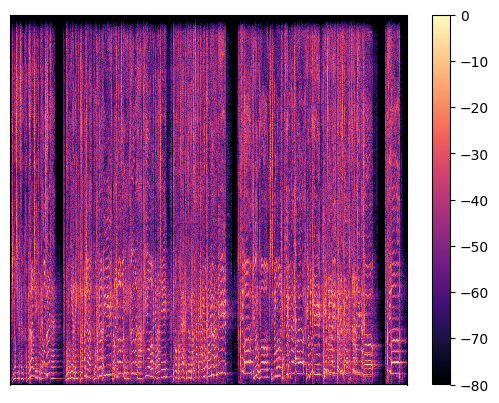

In [5]:
plt.figure()
librosa.display.specshow(S_db)
plt.colorbar()

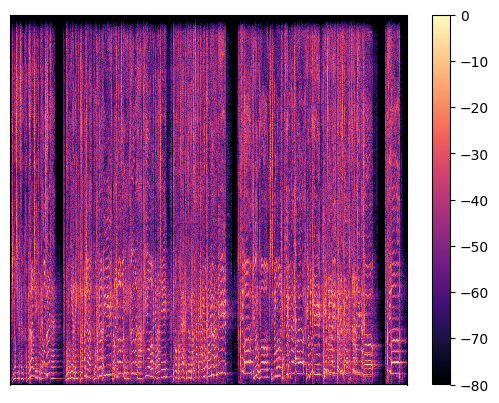

In [6]:
fig, ax = plt.subplots()
img = librosa.display.specshow(S_db, ax=ax)
fig.colorbar(img, ax=ax)

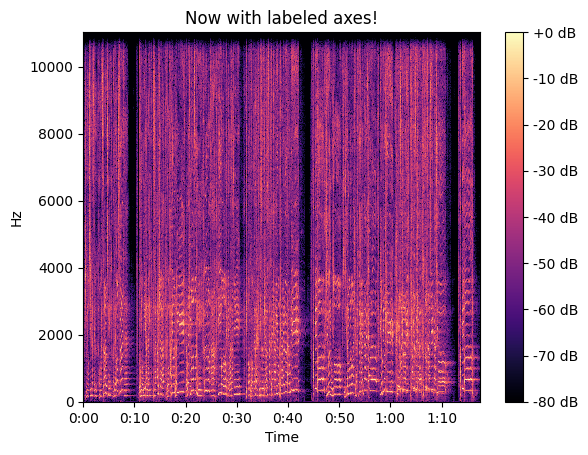

In [7]:
fig, ax = plt.subplots()
img = librosa.display.specshow(S_db, x_axis='time', y_axis='linear', ax=ax)
ax.set(title='Now with labeled axes!')
fig.colorbar(img, ax=ax, format='%+2.f dB')

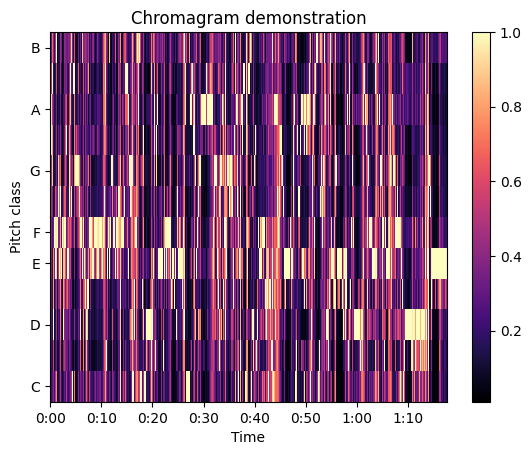

In [9]:
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
fig, ax = plt.subplots()
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax)
ax.set(title='Chromagram demonstration')
fig.colorbar(img, ax=ax)


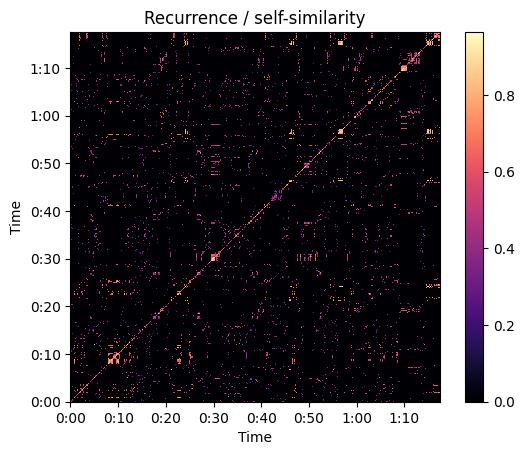

In [10]:
R = librosa.segment.recurrence_matrix(chroma, mode='affinity')
fig, ax = plt.subplots()
img = librosa.display.specshow(R, y_axis='time', x_axis='time', ax=ax)
ax.set(title='Recurrence / self-similarity')
fig.colorbar(img, ax=ax)

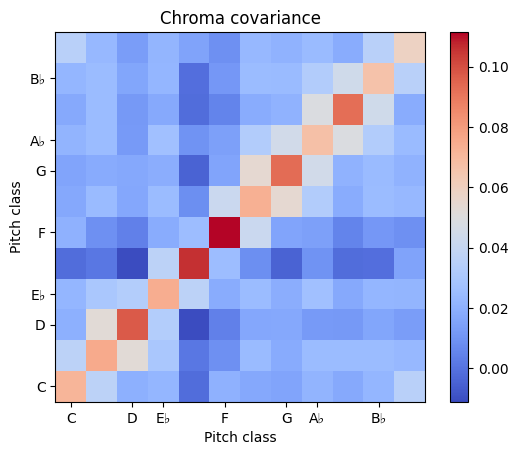

In [11]:
ccov = np.cov(chroma)
fig, ax = plt.subplots()
img = librosa.display.specshow(ccov, y_axis='chroma', x_axis='chroma',
                               key='Eb:maj', ax=ax)
ax.set(title='Chroma covariance')
fig.colorbar(img, ax=ax)